In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import glob

# 1. Load and Combine Data
# Assuming multiple CSV files in the current directory (e.g., one for each month)
#all_files = glob.glob("C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/raw/TTC Subway Delay Data since 2025.csv")
#df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/raw/csv/ttc-subway-delay-data-2025.csv')


# 2. Data Cleaning
# Remove rows where Min Delay is missing or 0 (often non-service-impacting incidents)
df = df.dropna(subset=['Min Delay', 'Time', 'Line', 'Station'])
df = df[df['Min Delay'] > 0]

# 3. Feature Engineering
# Convert 'Time' (HH:MM) to a numerical 'Hour' feature (0-23)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

# Select features and target
# 'Station' and 'Line' are categorical and need One-Hot Encoding
features = ['Hour', 'Station', 'Line']
X = pd.get_dummies(df[features], columns=['Station', 'Line'], drop_first=True)
y = df['Min Delay']

# 4. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Model
# Random Forest handles non-linear relationships better than Linear Regression for this data
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluation
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Root Mean Square Error: {rmse:.2f} minutes")
print(f"R-squared Score: {r2:.4f}")

# Optional: View which factors are most important
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Predictive Factors:")
print(importance.head(5))

Root Mean Square Error: 14.20 minutes
R-squared Score: -0.1265

Top 5 Predictive Factors:
Hour                              0.610422
Station_SHEPPARD TO EGLINTON      0.196567
Station_COXWELL STATION APPROA    0.037945
Station_DONLANDS TO GREENWOOD     0.019278
Station_KING TO UNION             0.019221
dtype: float64


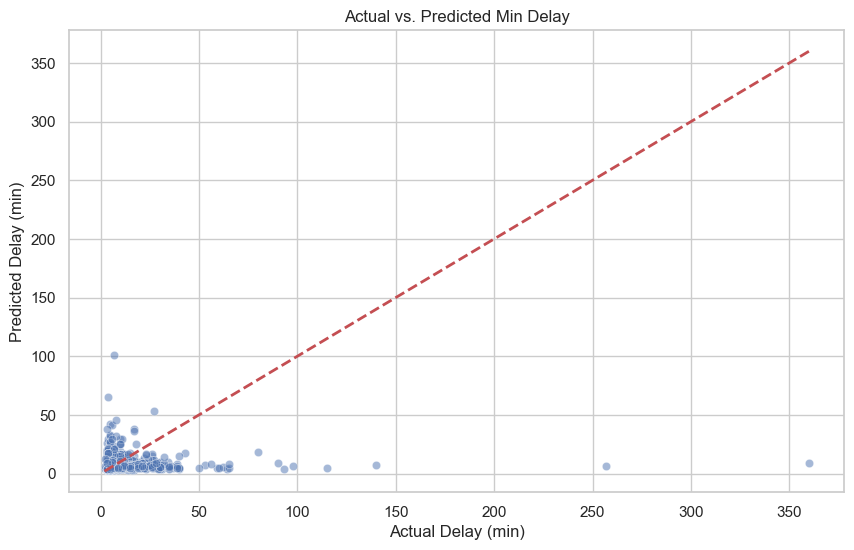

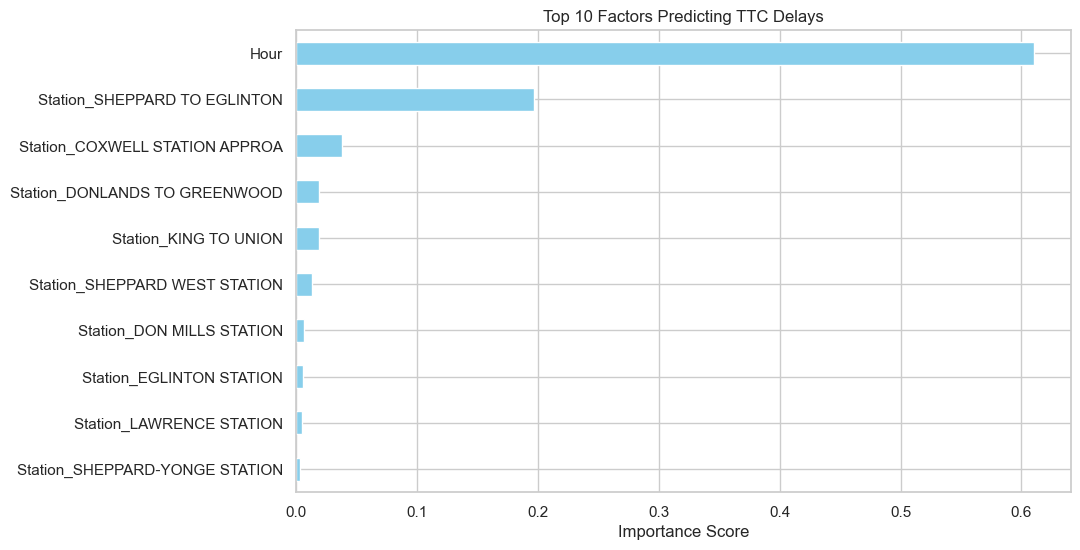

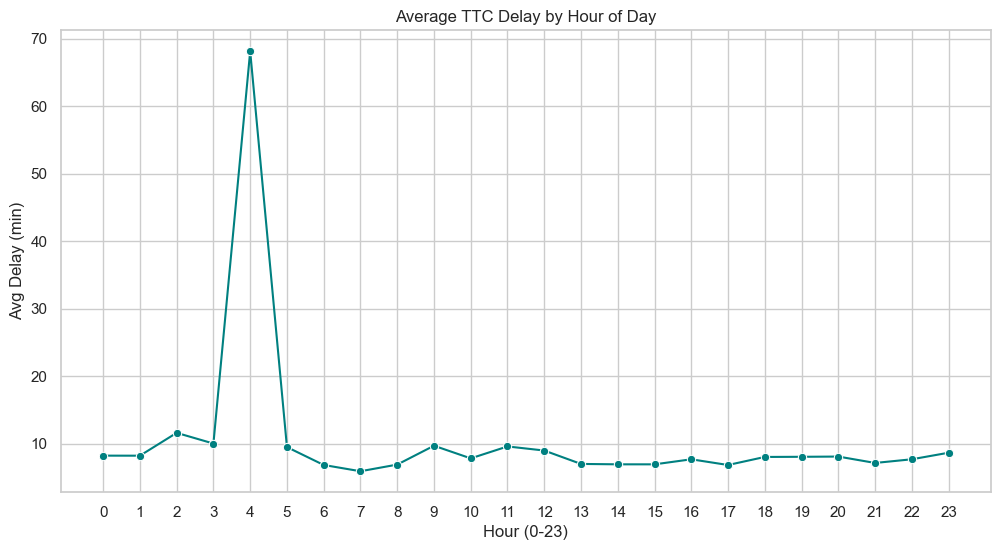

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# 1. Plot Actual vs. Predicted Delays
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual vs. Predicted Min Delay')
#plt.xlim(0,20)
#plt.ylim(0,25)
plt.xlabel('Actual Delay (min)')
plt.ylabel('Predicted Delay (min)')
plt.show()

# 2. Plot Top 10 Feature Importances
# This shows which factors (Time, Station, or Line) most influence the model
plt.figure(figsize=(10, 6))
importance.head(10).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Factors Predicting TTC Delays')
plt.xlabel('Importance Score')
plt.show()

# 3. Plot Average Delay by Hour (Historical Trend)
# This helps verify if the model is capturing peak-hour patterns
plt.figure(figsize=(12, 6))
hourly_avg = df.groupby('Hour')['Min Delay'].mean()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o', color='teal')
plt.title('Average TTC Delay by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Avg Delay (min)')
plt.xticks(range(0, 24))
plt.show()